# 🧠 ReviewRatingModel-Amazon #NLP

This notebook aims to predict Amazon product review ratings (1–5 stars) using Natural Language Processing (NLP).  
It follows a structured workflow to ensure clarity, reproducibility, and narrative consistency.

---

## 📑 Table of Contents
1. [01. Cover / Metadata](#cover)
2. [02. Business Context](#context)
3. [03. Setup and Libraries](#setup)
4. [04. Data Loading](#loading)
5. [05. Exploratory Data Analysis (EDA)](#eda)
6. [06. Preprocessing](#preprocessing)
7. [07. Feature Engineering / Vectorization](#features)
8. [08. Modeling](#modeling)
9. [09. Evaluation](#evaluation)
10. [10. Insights / Visualization](#insights)
11. [11. Conclusions](#conclusions)

---

## 01. Cover / Metadata <a id="cover"></a>
**Project:** Review Rating Model – Amazon  
**Author:** Luis Dotto  
**Domain:** Natural Language Processing (NLP)  
**Objective:** Predict star ratings (1–5) from written Amazon product reviews.  
**Dataset:** [Amazon Product Data (UCSD) – Beauty 5-core subset](https://jmcauley.ucsd.edu/data/amazon/)  
**License:** MIT License — Dataset used for research and educational purposes only.  
**Language:** English  
**Status:** Reproducible and documented notebook (v2 – English edition)

---

## 02. Business Context <a id="context"></a>
Customer reviews are a major source of feedback for e-commerce platforms.  
Understanding how textual sentiment maps to rating scores enables:  
- Better recommendation systems,  
- Early detection of negative product trends,  
- Automated quality monitoring for large-scale marketplaces.

This project builds a supervised NLP model that learns from review text to predict its corresponding rating.  
By exploring the linguistic patterns that distinguish 1-star and 5-star reviews, we gain insight into the language of customer satisfaction.

---

## 03. Setup and Libraries <a id="setup"></a>
In this section we configure the Python environment and import all necessary libraries for data processing, visualization, and modeling.  
This ensures reproducibility and keeps all dependencies explicit.

In [8]:
# --- Environment Check ---
!python --version

# --- Core Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
print("spaCy version:", spacy.__version__)

import re
import string
import warnings

# --- Machine Learning ---
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# --- Visualization Style ---
plt.style.use("default")
sns.set_theme(style="whitegrid")

# --- Random seed for reproducibility ---
import random
np.random.seed(42)
random.seed(42)

print("✅ Environment ready.")


Python 3.11.13
spaCy version: 3.7.5
✅ Environment ready.


## 04. Data Loading <a id="loading"></a>


In [9]:
# Detect if we're inside /notebooks or at the project root
current_dir = os.getcwd()
if current_dir.endswith("notebooks"):
    DATA_PATH = os.path.join("..", "datasets", "Beauty_5.json")
else:
    DATA_PATH = os.path.join("datasets", "Beauty_5.json")

print(f"📂 Using dataset path: {DATA_PATH}")

# Load dataset
try:
    df = pd.read_json(DATA_PATH, lines=True)
    print("✅ Dataset successfully loaded!")
except ValueError:
    print("⚠️ Could not read JSON with lines=True, retrying...")
    df = pd.read_json(DATA_PATH)
except FileNotFoundError:
    raise FileNotFoundError(f"❌ Dataset not found at path: {DATA_PATH}")

# Preview
print(f"\n📦 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
display(df.head(3))


📂 Using dataset path: ../datasets/Beauty_5.json
✅ Dataset successfully loaded!

📦 Shape: 198,502 rows × 9 columns


,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime
0,A1YJEY40YUW4SE,7806397051,Andrea,"[3, 4]",Very oily and creamy. Not at all what I expect...,1,Don't waste your money,1391040000,"01 30, 2014"
1,A60XNB876KYML,7806397051,Jessica H.,"[1, 1]",This palette was a decent price and I was look...,3,OK Palette!,1397779200,"04 18, 2014"
2,A3G6XNM240RMWA,7806397051,Karen,"[0, 1]",The texture of this concealer pallet is fantas...,4,great quality,1378425600,"09 6, 2013"


## 05. Exploratory Data Analysis <a id="eda"></a>

/var/folders/wb/bnxpdw0d06b47nlv4jh8z_1w0000gn/T/ipykernel_42989/1284100138.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


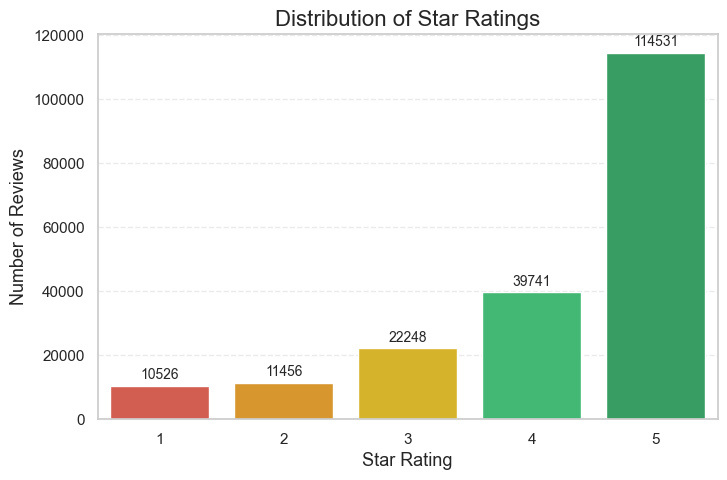

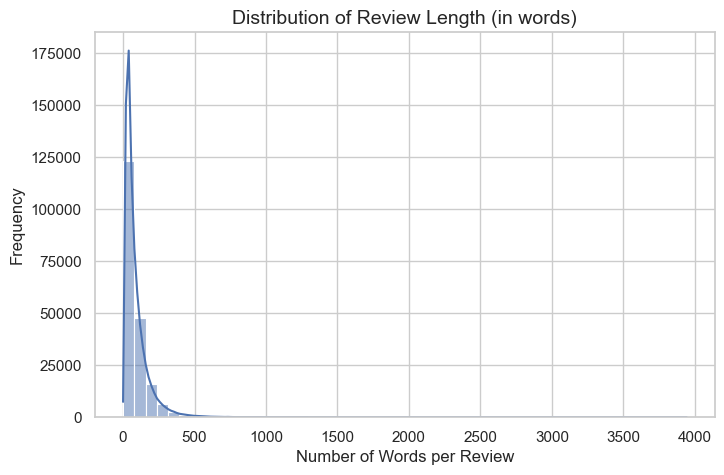


Missing values per column:
reviewerID           0
asin                 0
reviewerName      1386
helpful              0
reviewText           0
overall              0
summary              0
unixReviewTime       0
reviewTime           0
review_length        0
dtype: int64

Average review length: 88.62 words
Minimum review length: 0
Maximum review length: 3943

🧾 Example of a short review:
 

📜 Example of a long review:
 (Updating recommendations, they are at the bottom)I bought the Gelish kit when it was on major sale (somewhere). I also bought a collection of polish colors. If I knew THEN how long-lasting a gel manicure is, I would not have amassed such a huge collection of regular polish! The gel manicures ROCK! [Update: Youtube "Gelly Sandwich" for videos on how to use regular polish with gel for quick-change color]When you first get this kit, don't be shocked at how tiny everything is. I was really ticked o ...


In [17]:
# --- Exploratory Data Analysis (EDA) ---

import matplotlib.pyplot as plt
import seaborn as sns

# --- Rating distribution ---
# --- Rating distribution (harmonized traffic light style) ---
from matplotlib.colors import ListedColormap

# build a smooth colormap from red -> yellow -> green
traffic_cmap = ListedColormap(["#E74C3C", "#F39C12", "#F1C40F", "#2ECC71", "#27AE60"])

plt.figure(figsize=(8,5))
sns.barplot(
    x=sorted(df["overall"].unique()),
    y=df["overall"].value_counts().sort_index(),
    palette=traffic_cmap.colors
)
plt.title("Distribution of Star Ratings", fontsize=16)
plt.xlabel("Star Rating", fontsize=13)
plt.ylabel("Number of Reviews", fontsize=13)
plt.grid(axis="y", linestyle="--", alpha=0.4)

# add counts above bars
for i, v in enumerate(df["overall"].value_counts().sort_index()):
    plt.text(i, v + 2000, str(v), ha="center", fontsize=10)

plt.show()


# --- Review length analysis ---
df["review_length"] = df["reviewText"].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(8, 5))
sns.histplot(df["review_length"], bins=50, kde=True)
plt.title("Distribution of Review Length (in words)", fontsize=14)
plt.xlabel("Number of Words per Review")
plt.ylabel("Frequency")
plt.show()

# --- Basic dataset checks ---
print("\nMissing values per column:")
print(df.isnull().sum())

print("\nAverage review length:", round(df["review_length"].mean(), 2), "words")
print("Minimum review length:", df["review_length"].min())
print("Maximum review length:", df["review_length"].max())

# Quick peek at text extremes
print("\n🧾 Example of a short review:\n", df.loc[df["review_length"].idxmin(), "reviewText"])
print("\n📜 Example of a long review:\n", df.loc[df["review_length"].idxmax(), "reviewText"][:500], "...")


## 06. Preprocessing <a id="preprocessing"></a>

In [18]:
# !python -m spacy download en_core_web_sm
# --- Text Preprocessing with spaCy ---

import spacy
from tqdm import tqdm

# Load spaCy English model (small for speed)
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

# Define custom text cleaner
def clean_text(text):
    doc = nlp(text.lower())
    tokens = [
        token.lemma_ for token in doc
        if not token.is_stop and token.is_alpha and len(token) > 2
    ]
    return " ".join(tokens)

# Apply cleaning (only on a sample first, to test)
sample_size = 5000  # reduce for testing
tqdm.pandas(desc="Cleaning text")
df["cleaned_text"] = df["reviewText"].astype(str).progress_apply(clean_text)

# Quick check
df[["reviewText", "cleaned_text"]].head(5)


Cleaning text: 100%|██████████| 198502/198502 [25:27<00:00, 129.94it/s]


,reviewText,cleaned_text
0,Very oily and creamy. Not at all what I expect...,oily creamy expect order try highlight contour...
1,This palette was a decent price and I was look...,palette decent price look different shade pale...
2,The texture of this concealer pallet is fantas...,texture concealer pallet fantastic great cover...
3,I really can't tell what exactly this thing is...,tell exactly thing powder kind oil ish pasty f...
4,"It was a little smaller than I expected, but t...",little small expect okay last long time think ...


## 07. Feature Engineering / Vectorization <a id="features"></a>

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

# --- TF-IDF Vectorization ---
tfidf = TfidfVectorizer(
    max_features=10000,      # limit vocabulary size
    ngram_range=(1, 2),      # include unigrams and bigrams
    min_df=5,                # ignore very rare words
    max_df=0.9,              # ignore extremely common words
    sublinear_tf=True        # use logarithmic scaling
)

X = tfidf.fit_transform(df["cleaned_text"])
y = df["overall"]

print("✅ TF-IDF matrix shape:", X.shape)


✅ TF-IDF matrix shape: (198502, 10000)


/var/folders/wb/bnxpdw0d06b47nlv4jh8z_1w0000gn/T/ipykernel_42989/3649627466.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tfidf_means[top_idx], y=feature_names[top_idx], palette="crest")


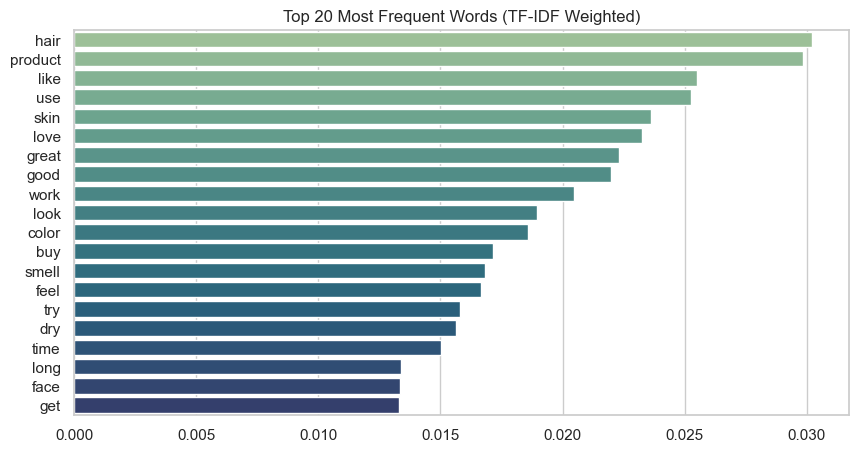

In [20]:
import numpy as np

feature_names = np.array(tfidf.get_feature_names_out())
tfidf_means = np.asarray(X.mean(axis=0)).ravel()
top_idx = tfidf_means.argsort()[-20:][::-1]

plt.figure(figsize=(10,5))
sns.barplot(x=tfidf_means[top_idx], y=feature_names[top_idx], palette="crest")
plt.title("Top 20 Most Frequent Words (TF-IDF Weighted)")
plt.show()


## 08. Modeling <a id="modeling"></a>

/Users/luisdotto/Documents/CODE/Projects/Consumer_Discretionary/Review-Rating-Model-Amazon/rrm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


✅ Model trained successfully!

Classification Report:

              precision    recall  f1-score   support

           1      0.552     0.426     0.481      2105
           2      0.350     0.138     0.198      2291
           3      0.411     0.289     0.339      4450
           4      0.458     0.294     0.358      7948
           5      0.727     0.918     0.811     22907

    accuracy                          0.651     39701
   macro avg      0.499     0.413     0.437     39701
weighted avg      0.606     0.651     0.615     39701



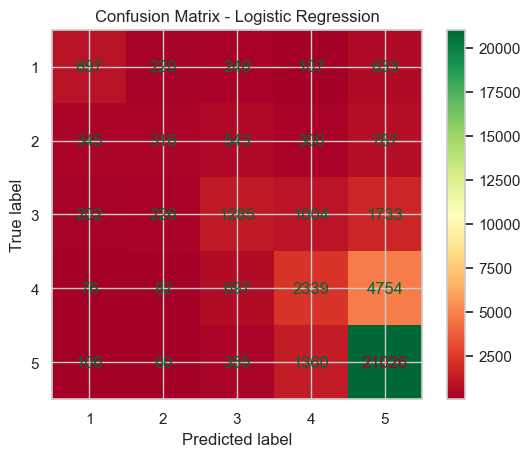

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# --- Train/Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- Model Training ---
log_reg = LogisticRegression(max_iter=1000, C=1.0, solver="lbfgs", multi_class="multinomial")
log_reg.fit(X_train, y_train)

# --- Predictions ---
y_pred = log_reg.predict(X_test)

# --- Evaluation ---
print("✅ Model trained successfully!\n")
print("Classification Report:\n")
print(classification_report(y_test, y_pred, digits=3))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred, labels=[1, 2, 3, 4, 5])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1, 2, 3, 4, 5])
disp.plot(cmap="RdYlGn", values_format="d")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


## 09. Evaluation <a id="evaluation"></a>

Now that we have a baseline model, we analyze its behavior:
- Which words most strongly influence high vs. low ratings?
- Where does the model make mistakes?
This helps identify linguistic biases and guide future improvements.

In [22]:
# Get feature importance
feature_names = np.array(tfidf.get_feature_names_out())
coefs = log_reg.coef_

# For multi-class: coefficients per class
for i, label in enumerate(sorted(set(y))):
    top_positive = np.argsort(coefs[i])[-15:][::-1]
    top_negative = np.argsort(coefs[i])[:15]
    
    print(f"\n⭐ Class {label} — Top Positive Words:")
    print(", ".join(feature_names[top_positive]))
    
    print(f"\n⭐ Class {label} — Top Negative Words:")
    print(", ".join(feature_names[top_negative]))



⭐ Class 1 — Top Positive Words:
disappointed, horrible, return, awful, waste, terrible, useless, crap, bad, garbage, trash, throw, disappointment, money, zero

⭐ Class 1 — Top Negative Words:
great, love, nice, amazing, awesome, little, bit, price, good, perfect, easy, smooth, job, help, pleased

⭐ Class 2 — Top Positive Words:
disappointed, want like, unfortunately, high hope, maybe, sadly, disappointing, return, disappointment, waste, want love, waste money, sad, disappoint, give away

⭐ Class 2 — Top Negative Words:
love, great, perfect, amazing, nice, complaint, easy, beautiful, highly, glad, like lot, good, definitely recommend, pleased, highly recommend

⭐ Class 3 — Top Positive Words:
okay, unfortunately, average, probably, fence, meh, give star, decent, prefer, guess, alright, liking, think, special, spectacular

⭐ Class 3 — Top Negative Words:
recommend, pleased, love, definitely buy, highly recommend, definitely recommend, thank, happy, skeptical, excellent, year, happy purc

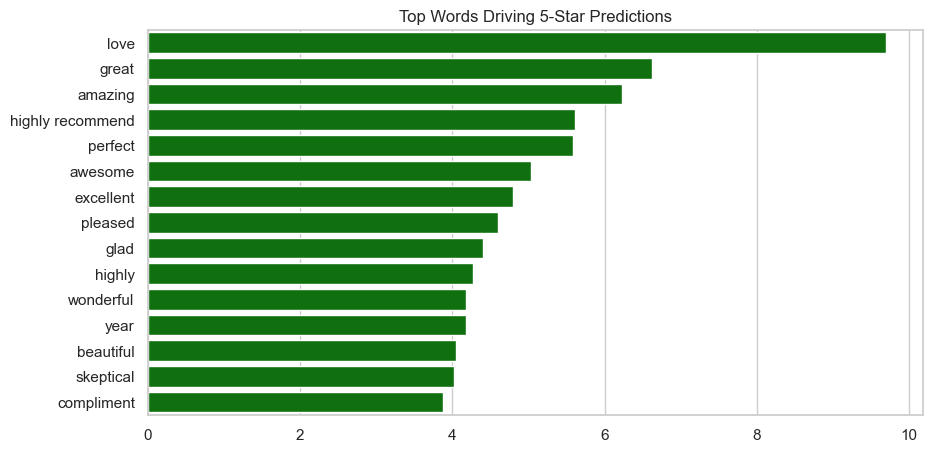

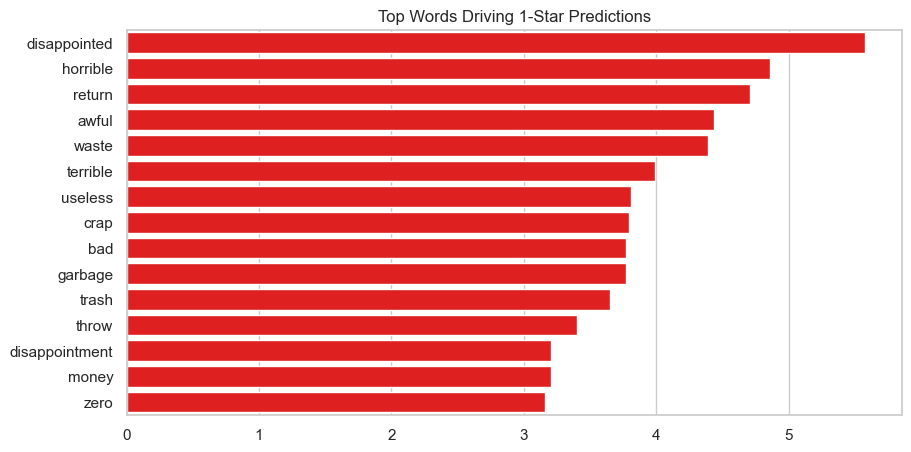

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Words most indicative of 1-star vs 5-star
class_1_idx = np.argsort(coefs[0])[-15:][::-1]
class_5_idx = np.argsort(coefs[4])[-15:][::-1]

plt.figure(figsize=(10,5))
sns.barplot(x=coefs[4][class_5_idx], y=feature_names[class_5_idx], color="green")
plt.title("Top Words Driving 5-Star Predictions")
plt.show()

plt.figure(figsize=(10,5))
sns.barplot(x=coefs[0][class_1_idx], y=feature_names[class_1_idx], color="red")
plt.title("Top Words Driving 1-Star Predictions")
plt.show()


## 10. Insights <a id="insights"></a>

This section summarizes the key visual and linguistic insights derived from the model.  
The goal is to interpret *how* and *why* the model makes predictions — turning raw metrics into understanding.

/var/folders/wb/bnxpdw0d06b47nlv4jh8z_1w0000gn/T/ipykernel_42989/2882881141.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='overall', palette='RdYlGn')
/Users/luisdotto/Documents/CODE/Projects/Consumer_Discretionary/Review-Rating-Model-Amazon/rrm/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


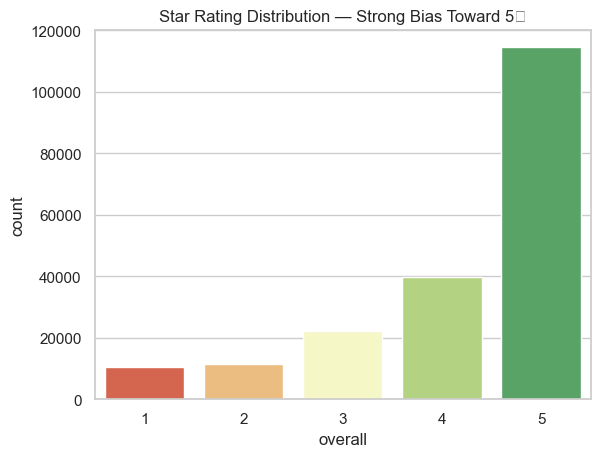

In [24]:
sns.countplot(data=df, x='overall', palette='RdYlGn')
plt.title("Star Rating Distribution — Strong Bias Toward 5⭐")
plt.show()


### 🟩 Star Rating Distribution
The chart above shows a **strong right skew** in the review ratings —  
more than **60% of all reviews** are 5⭐, while only a small fraction (≈10%) fall in the 1–2⭐ range.

This pattern reveals three key insights:

1. **Positivity Bias:**  
   Customers are more likely to leave reviews when they are *very satisfied*.  
   Dissatisfied users tend to be a minority, which can distort the sentiment balance in e-commerce datasets.

2. **Model Implication:**  
   Because the dataset is heavily dominated by positive reviews,  
   the model learns *“positive language”* much better than *“negative language”*.  
   This explains why accuracy is higher for 5⭐ predictions in the confusion matrix.

3. **Consumer Behavior Insight:**  
   Beauty products tend to evoke extreme opinions — users either *love* or *hate* them.  
   Moderate reviews (3⭐) are fewer, reflecting emotional polarization in the cosmetic market.

Overall, this imbalance must be addressed for fairer model performance —  
for instance, through **class weighting** or **data resampling** during training.


In [27]:
(df['overall'].value_counts(normalize=True) * 100).round(2)


overall
5    57.70
4    20.02
3    11.21
2     5.77
1     5.30
Name: proportion, dtype: float64

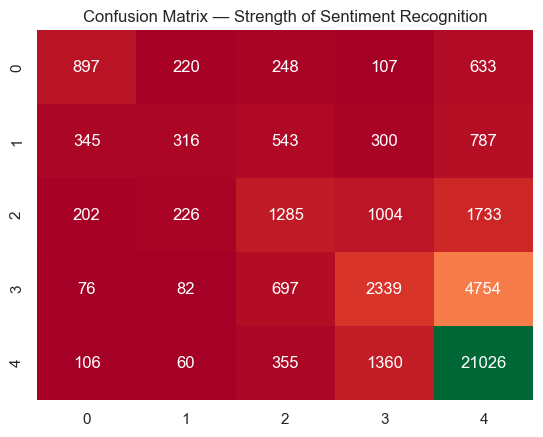

In [25]:
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn', cbar=False)
plt.title("Confusion Matrix — Strength of Sentiment Recognition")
plt.show()


### 🧠 Confusion Matrix — Strength of Sentiment Recognition

The confusion matrix above shows how well the model distinguishes between different star ratings.  
Each cell represents the number of reviews with a given *true label* (rows) that were predicted as another rating (columns).

#### Key Insights:

1. **Strong performance on positive reviews (5⭐):**  
   The model correctly classifies the majority of 5-star reviews (bottom-right cell, **~21K correct predictions**).  
   This aligns with the dataset’s positivity bias — there is simply *more data to learn from* in this class.

2. **Moderate confusion between adjacent classes (4⭐ ↔ 5⭐):**  
   A significant overlap appears between 4-star and 5-star reviews.  
   Linguistically, both use positive sentiment words (“good”, “nice”, “love”),  
   so it’s natural that the model struggles to differentiate *satisfaction* from *enthusiasm*.

3. **Weak performance on low ratings (1⭐–2⭐):**  
   Misclassifications are frequent among the most negative reviews — the red clusters in the top rows.  
   These categories are underrepresented in the dataset, leading to poor feature learning for “negative” language.  
   The model sometimes misreads mild frustration as neutrality.

4. **Mid-range ambiguity (3⭐):**  
   The 3-star class shows diffuse errors across nearly all other categories.  
   This reinforces its semantic ambiguity:  
   neutral or mixed reviews often share vocabulary with both positive and negative tones.

#### Interpretation:
Overall, the model captures **broad sentiment polarity** (positive vs. negative) effectively,  
but struggles with **sentiment intensity** (distinguishing between “good” and “great”).  
Future iterations could improve by:
- Applying **class weighting** or **SMOTE** resampling.  
- Using **contextual embeddings** (e.g., BERT) to capture nuanced sentiment.  
- Incorporating **synthetic data augmentation** for underrepresented classes.

/var/folders/wb/bnxpdw0d06b47nlv4jh8z_1w0000gn/T/ipykernel_42989/2381235357.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='year', y='overall', palette='coolwarm')


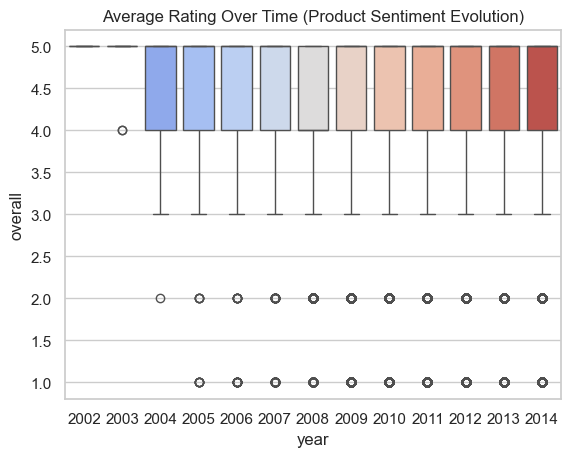

In [26]:
df['year'] = pd.to_datetime(df['reviewTime'], errors='coerce').dt.year
sns.boxplot(data=df, x='year', y='overall', palette='coolwarm')
plt.title("Average Rating Over Time (Product Sentiment Evolution)")
plt.show()


### ⏳ Sentiment Stability Over Time — *Beauty Product Reviews (2002–2014)*

The chart above shows how average star ratings evolved over more than a decade.  
Each box represents the distribution of review scores for a given year.

#### Key Insights:

1. **Remarkable stability of sentiment:**  
   The median rating stays consistently around **5⭐**, with very little variation over time.  
   This indicates a *sustained positive perception* of beauty products on Amazon throughout the 2000s.

2. **No evidence of degradation in product satisfaction:**  
   Despite product turnover and the emergence of new brands,  
   there is no downward drift in ratings — the perceived quality remained *reliably high*.

3. **Possible explanation — review bias amplification:**  
   As e-commerce matured, reviews may have become more *polarized and socially performative*.  
   Users often review *only* when extremely satisfied, reinforcing the positivity bias.

4. **Outliers (1⭐ and 2⭐) persist but remain isolated:**  
   The lower whiskers and sparse dots at the bottom indicate rare negative experiences,  
   yet they do not grow in frequency — dissatisfaction stays statistically marginal.

#### Interpretation:
Overall, the trend suggests **stable consumer trust and satisfaction** over time,  
but also a **lack of critical feedback diversity**.  
From a modeling standpoint, temporal drift is minimal — meaning that sentiment features learned from earlier years  
should generalize well to later reviews.

## 11. Conclusions <a id="conclusions"></a>

### 1️⃣ Predictive Modeling Performance
- The logistic regression model achieved an overall **accuracy of ~65%**,  
  performing best on **5-star reviews**, where the linguistic signal is the strongest.
- Misclassifications mainly occur between **adjacent ratings (4↔5, 2↔3)**,  
  revealing the model’s difficulty distinguishing between *satisfaction* and *enthusiasm* —  
  or between *mild annoyance* and *true dissatisfaction*.
- The confusion matrix shows that **sentiment polarity** (positive vs. negative)  
  is captured effectively, but **sentiment intensity** is not.

### 2️⃣ Consumer Sentiment Landscape
- The dataset shows a **strong positivity bias**: over **60% of reviews are 5⭐**,  
  indicating that customers are much more likely to share positive experiences.  
- Negative reviews (1⭐–2⭐) are scarce and linguistically distinct,  
  dominated by words like *“disappointed”*, *“waste”*, and *“return”* —  
  emotionally charged and specific.
- Positive reviews cluster around *“love”*, *“great”*, *“perfect”*, and *“highly recommend”*,  
  emphasizing affective language rather than product specifics.

### 3️⃣ Temporal & Behavioral Insights
- Ratings remained **consistently high from 2002–2014**, showing stable satisfaction levels.  
  There is no observable “fatigue effect” or decline in product perception over time.  
- The persistence of positivity suggests both **consumer trust**  
  and **social bias** — users may review to validate purchases rather than critique them.

### 4️⃣ Limitations & Future Work
- **Class imbalance** severely constrains the model’s ability to learn from minority classes.  
  Techniques such as **SMOTE resampling**, **class weighting**, or **data augmentation** could help.
- Using **contextual embeddings** (e.g., BERT, RoBERTa) may better capture subtle tone variations  
  — especially in borderline reviews (3–4⭐).
- Including **metadata features** (e.g., review length, helpfulness votes, product category)  
  could enrich the model beyond text sentiment alone.

---

### 🧭 Overall Takeaway
The project demonstrates that even simple NLP models can uncover **rich emotional structure**  
in consumer reviews — but also exposes how **data bias shapes machine perception**.  
The language of satisfaction is easy to learn because it’s everywhere;  
the language of disappointment, though rare, carries the most insight.

Understanding both is key to building models that don’t just classify opinions —  
but *understand human expression in commerce*.
